In [75]:
import pandas as pd

DATA_PATH = "../data/raw/"

calendar = pd.read_csv(DATA_PATH + "calendar.csv")
prices = pd.read_csv(DATA_PATH + "sell_prices.csv")
sales = pd.read_csv(DATA_PATH + "sales_train_evaluation.csv")

In [76]:
calendar.shape, prices.shape, sales.shape

((1969, 14), (6841121, 4), (30490, 1947))

In [77]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [78]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [79]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [80]:
sales.shape

(30490, 1947)

In [81]:
day_cols = [f"d_{i}" for i in range(1,150)]

In [82]:
[c for c in sales.columns if c.startswith("d_")][:20]

['d_1',
 'd_2',
 'd_3',
 'd_4',
 'd_5',
 'd_6',
 'd_7',
 'd_8',
 'd_9',
 'd_10',
 'd_11',
 'd_12',
 'd_13',
 'd_14',
 'd_15',
 'd_16',
 'd_17',
 'd_18',
 'd_19',
 'd_20']

In [83]:
id_cols = ["id", "item_id","dept_id", "cat_id", "store_id", "state_id"]

In [84]:
sales = sales.iloc[:2000]

In [85]:

sales_long = sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="units_sold"
)

In [86]:
sales_long.shape

(298000, 8)

In [87]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [88]:
sales_long["d"].nunique()

149

In [89]:
sales_long = sales_long.merge(
    calendar,
    how="left",
    on="d"
)

In [90]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [91]:
sales_long.shape

(298000, 21)

In [92]:
sales_long = sales_long.merge(
    prices,
    how="left",
    on=["item_id", "store_id", "wm_yr_wk"]
)

In [93]:
sales_long.shape

(298000, 22)

In [94]:
sales_long["sell_price"] = sales_long["sell_price"].fillna(0)
sales_long["revenue"] = sales_long["units_sold"] * sales_long["sell_price"]

In [95]:
sales_long[["item_id", "store_id", "date", "units_sold", "sell_price", "revenue"]].head()

,item_id,store_id,date,units_sold,sell_price,revenue
0,HOBBIES_1_001,CA_1,2011-01-29,0,0.0,0.0
1,HOBBIES_1_002,CA_1,2011-01-29,0,0.0,0.0
2,HOBBIES_1_003,CA_1,2011-01-29,0,0.0,0.0
3,HOBBIES_1_004,CA_1,2011-01-29,0,0.0,0.0
4,HOBBIES_1_005,CA_1,2011-01-29,0,0.0,0.0


In [96]:
sales_long["revenue"].sum()

644727.9099999998

In [97]:
sales_long.groupby("cat_id")["revenue"].sum().sort_values(ascending=False)

cat_id
HOUSEHOLD    314417.18
HOBBIES      171507.30
FOODS        158803.43
Name: revenue, dtype: float64

In [98]:
import os
os.makedirs("../data/processed", exist_ok=True)

In [99]:
sales_long.to_parquet("../data/processed/fact_sales_raw.parquet")

In [100]:
dim_date = sales_long[[
    "date", "weekday", "wday", "month", "year",
    "event_name_1", "event_type_1",
    "event_name_2", "event_type_2",
    "snap_CA", "snap_TX", "snap_WI"
]].drop_duplicates().reset_index(drop=True)

In [101]:
dim_item = sales_long[[
    "item_id", "dept_id", "cat_id"
]].drop_duplicates().reset_index(drop=True)

In [102]:
dim_store = sales_long[[
    "store_id", "state_id"
]].drop_duplicates().reset_index(drop=True)

In [103]:
dim_date.shape, dim_item.shape, dim_store.shape

((149, 12), (2000, 3), (1, 2))

In [104]:
dim_date.to_parquet("../data/processed/dim_date.parquet", index=False)

dim_item.to_parquet("../data/processed/dim_item.parquet", index=False)

dim_store.to_parquet("../data/processed/dim_store.parquet", index=False)

In [105]:
sales_long["date"] = pd.to_datetime(sales_long["date"])

In [106]:
sales_long = sales_long.sort_values(
    ["item_id", "store_id", "date"]
)

In [107]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,revenue
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,6.0
3612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,0.0
5612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,0.0
7612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,2011,NaN,NaN,NaN,NaN,1,1,0,2.0,2.0
9612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,2011,NaN,NaN,NaN,NaN,1,0,1,2.0,8.0


In [108]:
sales_long.shape

(298000, 23)

In [109]:
sales_long["lag_7"] = sales_long.groupby(
    ["item_id", "store_id"]
)["units_sold"].shift(7)

sales_long["lag_14"] = sales_long.groupby(
    ["item_id", "store_id"]
)["units_sold"].shift(14)

sales_long["lag_28"] = sales_long.groupby(
    ["item_id", "store_id"]
)["units_sold"].shift(28)

In [110]:
sales_long.shape

(298000, 26)

In [111]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,revenue,lag_7,lag_14,lag_28
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,NaN,NaN,0,0,0,2.0,6.0,NaN,NaN,NaN
3612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,NaN,NaN,0,0,0,2.0,0.0,NaN,NaN,NaN
5612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,NaN,NaN,0,0,0,2.0,0.0,NaN,NaN,NaN
7612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,NaN,NaN,1,1,0,2.0,2.0,NaN,NaN,NaN
9612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,NaN,NaN,1,0,1,2.0,8.0,NaN,NaN,NaN


In [112]:
sales_long["rolling_mean_7"] = sales_long.groupby(
    ["item_id", "store_id"]
    )["units_sold"].shift(1).rolling(7).mean()

In [113]:
sales_long["rolling_mean_14"] = (
    sales_long.groupby(["item_id","store_id"])["units_sold"]
    .shift(1)
    .rolling(14)
    .mean()
)

In [114]:
sales_long["rolling_mean_28"] = (
    sales_long.groupby(["item_id","store_id"])["units_sold"]
    .shift(1)
    .rolling(28)
    .mean()
)

In [115]:
sales_long["lag_7"] = sales_long["lag_7"].fillna(0)
sales_long["lag_14"] = sales_long["lag_14"].fillna(0)
sales_long["lag_28"] = sales_long["lag_28"].fillna(0)

sales_long["rolling_mean_7"] = sales_long["rolling_mean_7"].fillna(0)
sales_long["rolling_mean_7"] = sales_long["rolling_mean_14"].fillna(0)
sales_long["rolling_mean_7"] = sales_long["rolling_mean_28"].fillna(0)

In [116]:
sales_long["price_change"] = sales_long.groupby(
    ["item_id", "store_id"]
)["sell_price"].pct_change()

In [117]:
sales_long.shape

(298000, 30)

In [118]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,...,snap_WI,sell_price,revenue,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,price_change
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,0,2.0,6.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0
5612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0
7612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,0,2.0,2.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0
9612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,1,2.0,8.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0


In [119]:
sales_long.shape

(298000, 30)

In [120]:
sales_long["day"] = sales_long["date"].dt.day
sales_long["week"] = sales_long["date"].dt.isocalendar().week
sales_long["month"] = sales_long["date"].dt.month
sales_long["year"] = sales_long["date"].dt.year

In [121]:
sales_long.dropna(subset=["sell_price"])

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,...,revenue,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,price_change,day,week
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,6.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,29,4
3612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,0.0,30,4
5612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,0.0,31,5
7612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,2.0,0.0,0.0,0.0,0.000000,NaN,NaN,0.0,1,5
9612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,8.0,0.0,0.0,0.0,0.000000,NaN,NaN,0.0,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289611,HOUSEHOLD_2_516_CA_1_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_145,0,2011-06-22,11121,...,0.0,0.0,0.0,0.0,0.142857,0.142857,0.142857,0.0,22,25
291611,HOUSEHOLD_2_516_CA_1_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_146,0,2011-06-23,11121,...,0.0,0.0,1.0,0.0,0.142857,0.142857,0.142857,0.0,23,25
293611,HOUSEHOLD_2_516_CA_1_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_147,0,2011-06-24,11121,...,0.0,0.0,0.0,0.0,0.142857,0.071429,0.142857,0.0,24,25
295611,HOUSEHOLD_2_516_CA_1_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_148,0,2011-06-25,11122,...,0.0,0.0,0.0,0.0,0.142857,0.071429,0.142857,0.0,25,25


In [122]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,...,revenue,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,price_change,day,week
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,6.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,29,4
3612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,30,4
5612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,31,5
7612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,2.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,1,5
9612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,8.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,2,5


In [123]:
sales_long["price_change"] = sales_long["price_change"].fillna(0)

In [124]:
sales_long.shape

(298000, 32)

In [125]:
features = [
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "price_change",
    "month",
    "week",
    "day"
]

target = ["units_sold"]

In [126]:
split_date = sales_long["date"].max() - pd.Timedelta(days=30)

train_data = sales_long[sales_long["date"] <= split_date]
test_data = sales_long[sales_long["date"] > split_date]

In [127]:
x_train = train_data[features]
y_train = train_data[target]

x_test = test_data[features]
y_test = test_data[target]

In [128]:
x_train.isna().sum()

lag_7                  0
lag_14                 0
lag_28                 0
rolling_mean_7         0
rolling_mean_14    28000
rolling_mean_28    56000
price_change           0
month                  0
week                   0
day                    0
dtype: int64

In [129]:
x_train.shape, x_test.shape

((238000, 10), (60000, 10))

In [130]:
y_train.isna().sum()

units_sold    0
dtype: int64

In [131]:
import numpy as np
x_train = x_train.replace([np.inf, -np.inf], 0)
x_test = x_test.replace([np.inf, -np.inf], 0)

In [132]:
np.isinf(x_train).sum()

lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
price_change       0
month              0
week               0
day                0
dtype: int64

In [133]:
import lightgbm as lgb

In [134]:
model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42
)

In [135]:
model.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1063
[LightGBM] [Info] Number of data points in the train set: 238000, number of used features: 10
[LightGBM] [Info] Start training from score 0.628189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMRegressor(max_depth=10, n_estimators=200, random_state=42)

In [136]:
predictions = model.predict(x_test)

In [137]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Rmse", rmse)

Rmse 1.794458573061018


In [138]:
sales_long["d"].nunique()

149

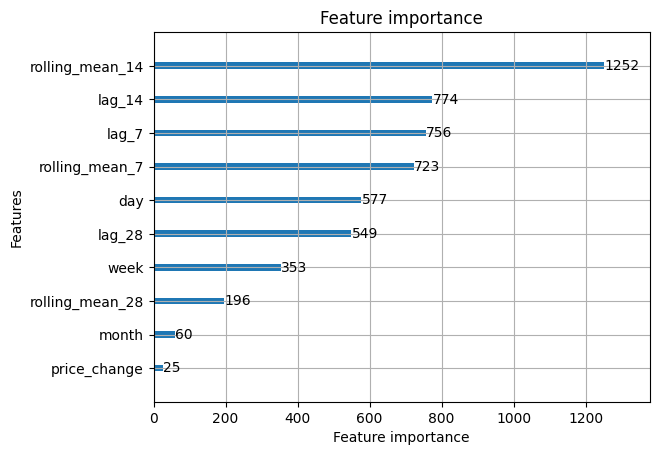

In [139]:
import matplotlib.pyplot as plt

lgb.plot_importance(model)
plt.show()

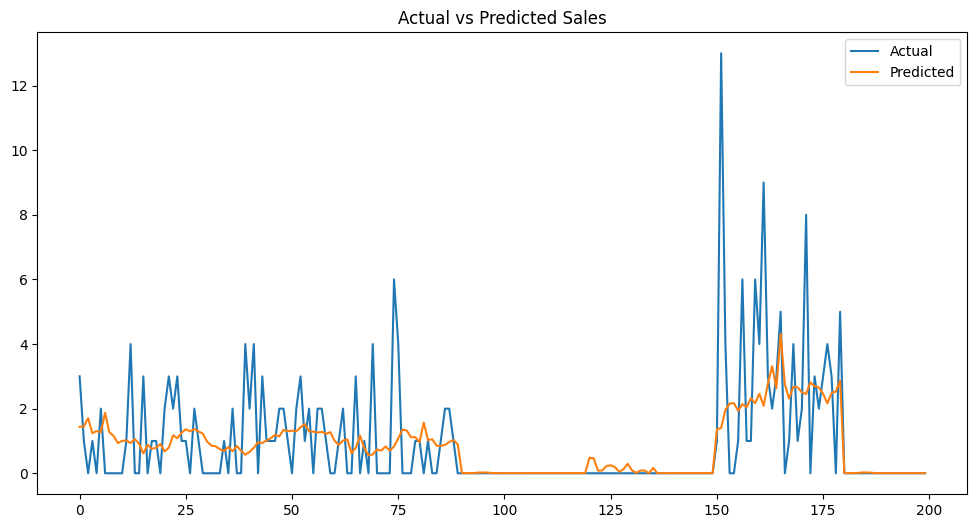

In [140]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [141]:
product_data = sales_long[(sales_long["item_id"]=="FOODS_1_001") & (sales_long["store_id"]=="CA_1")]

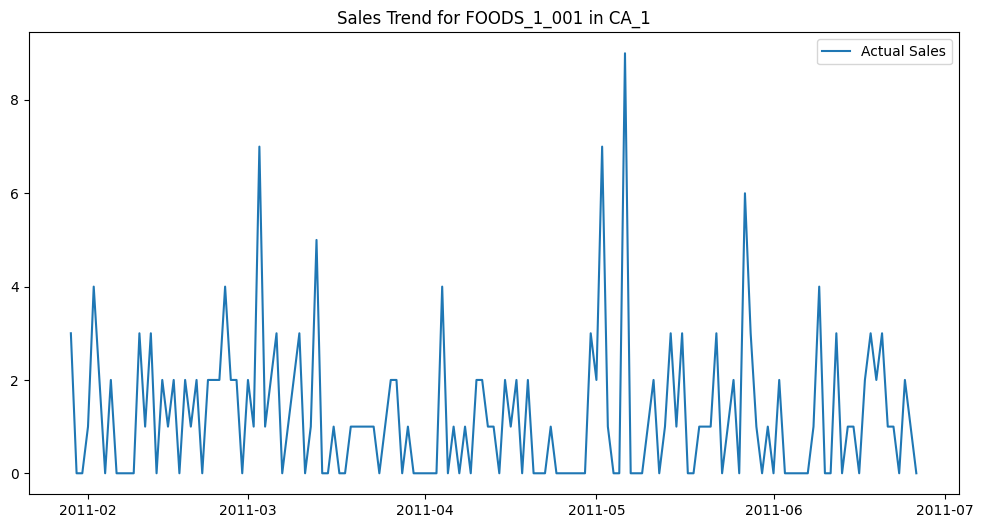

In [142]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(product_data["date"], product_data["units_sold"], label="Actual Sales")
plt.title("Sales Trend for FOODS_1_001 in CA_1")
plt.legend()
plt.show()

In [143]:
final_df = test_data.copy()
final_df["predicted_units_sold"] = predictions

In [145]:
final_df = final_df[[
    "date",
    "item_id",
    "store_id",
    "units_sold",
    "predicted_units_sold",
    "revenue"
]]

In [146]:
final_df.to_csv("../data/processed/dashboard_data.csv", index=False)

In [147]:
final_df.head()

,date,item_id,store_id,units_sold,predicted_units_sold,revenue
239612,2011-05-28,FOODS_1_001,CA_1,3,1.438369,6.0
241612,2011-05-29,FOODS_1_001,CA_1,1,1.450324,2.0
243612,2011-05-30,FOODS_1_001,CA_1,0,1.707345,0.0
245612,2011-05-31,FOODS_1_001,CA_1,1,1.240847,2.0
247612,2011-06-01,FOODS_1_001,CA_1,0,1.307012,0.0


In [148]:
final_df.shape

(60000, 6)